In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("/content/AAPL.xlsx")

df.columns = df.columns.str.strip()

cols = ["Open", "High", "Low", "Close", "Volume"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=cols)
df = df.drop_duplicates()


In [5]:
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

In [6]:

df["Daily_Return"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100


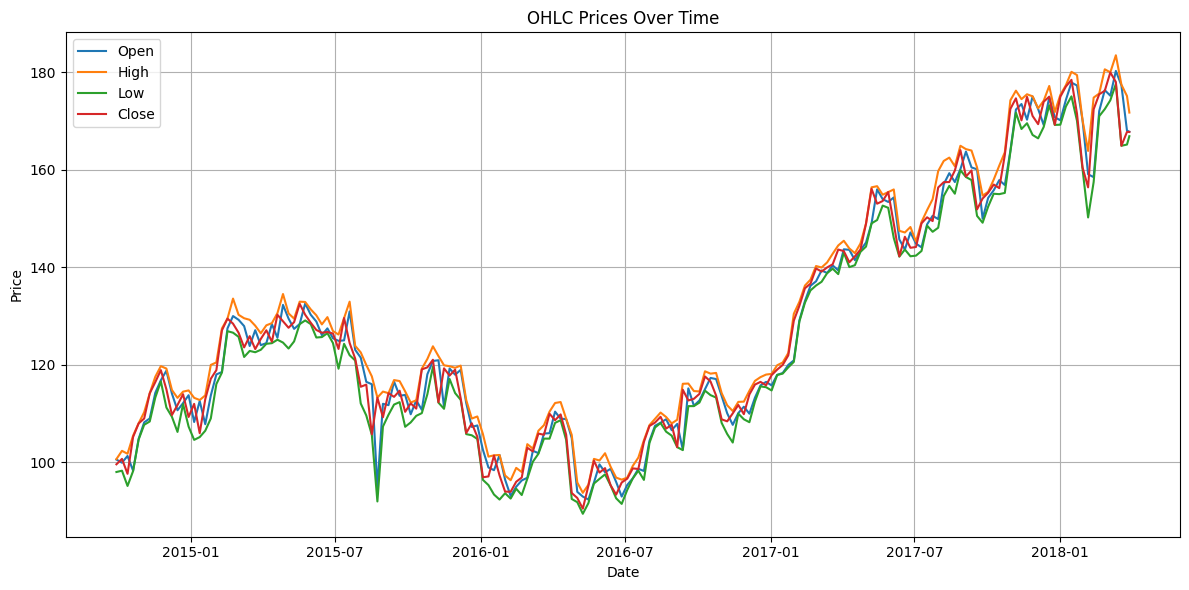

In [7]:
x = df["Date"] if "Date" in df.columns else df.index

plt.figure(figsize=(12, 6))

plt.plot(x, df["Open"], label="Open")
plt.plot(x, df["High"], label="High")
plt.plot(x, df["Low"], label="Low")
plt.plot(x, df["Close"], label="Close")

plt.title("OHLC Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

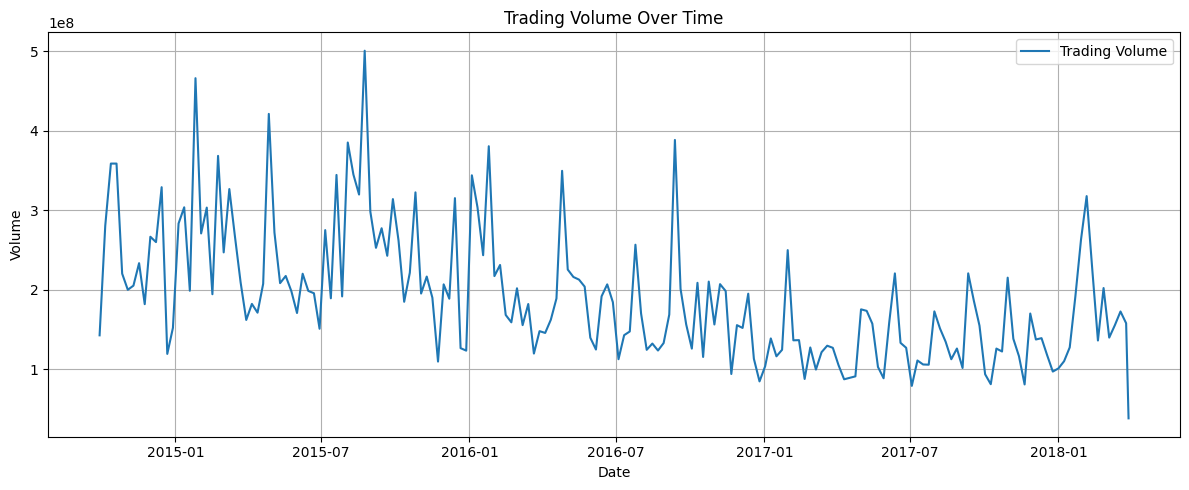

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(x, df["Volume"], label="Trading Volume")

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


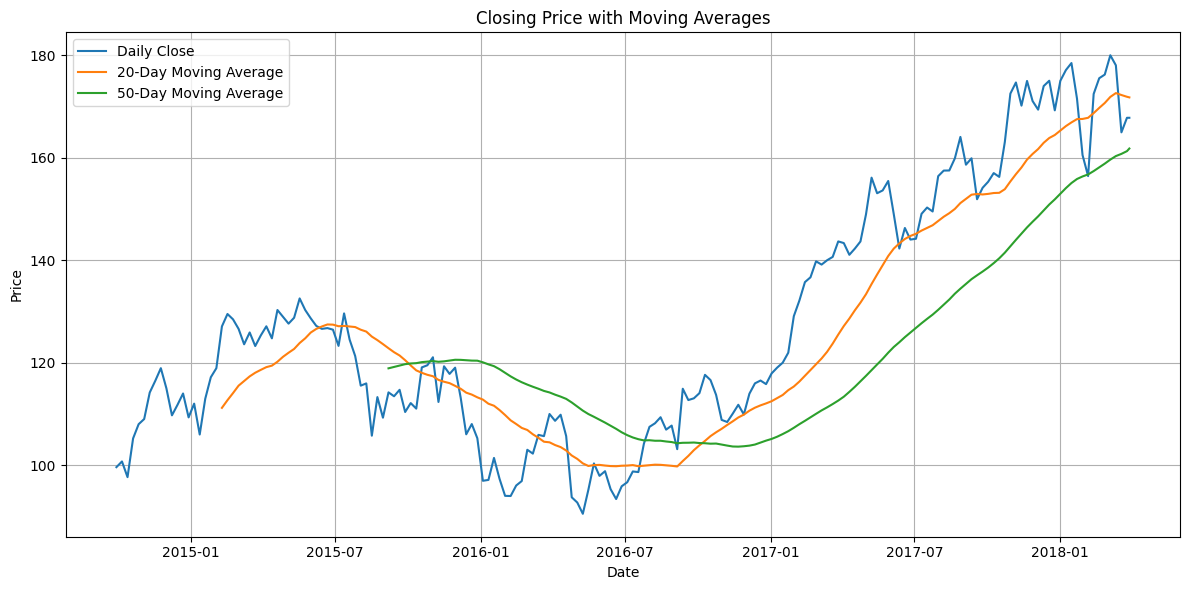

In [9]:
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(12, 6))

plt.plot(x, df["Close"], label="Daily Close")
plt.plot(x, df["MA_20"], label="20-Day Moving Average")
plt.plot(x, df["MA_50"], label="50-Day Moving Average")

plt.title("Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

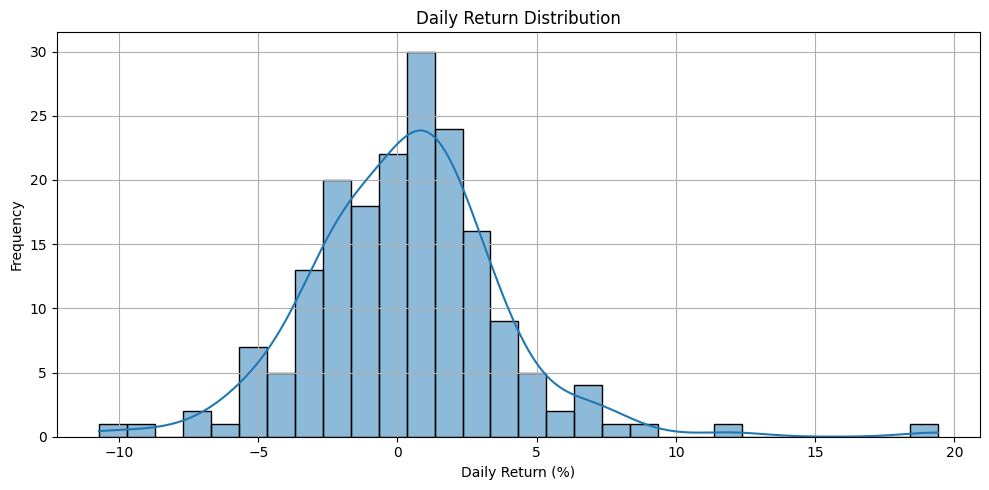

In [10]:

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Daily_Return"],
    bins=30,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
mean_return = df["Daily_Return"].mean()
variance_return = df["Daily_Return"].var()
std_return = df["Daily_Return"].std()

high_volatility = df[
    abs(df["Daily_Return"]) > 2 * std_return
]

In [12]:
print("\nReturn Statistics")
print("--------------------------------")
print("Mean Return          :", round(mean_return, 4), "%")
print("Variance             :", round(variance_return, 4))
print("Standard Deviation   :", round(std_return, 4), "%")


Return Statistics
--------------------------------
Mean Return          : 0.3072 %
Variance             : 12.2892
Standard Deviation   : 3.5056 %


In [13]:
print("\nPrice Statistics")
print("--------------------------------")
print("Highest Closing Price:", df["Close"].max())
print("Lowest Closing Price :", df["Close"].min())


Price Statistics
--------------------------------
Highest Closing Price: 179.979996
Lowest Closing Price : 90.519997


In [14]:
print("\nTrading Volume")
print("--------------------------------")
print("Average Volume       :", round(df["Volume"].mean(), 2))
print("Maximum Volume       :", df["Volume"].max())


Trading Volume
--------------------------------
Average Volume       : 191016776.11
Maximum Volume       : 500363000


In [15]:
print("\nHigh-Volatility Days")
print("--------------------------------")
print("Number of Days       :", len(high_volatility))

if len(high_volatility) > 0:
    print("\nHigh-Volatility Records:")
    print(
        high_volatility[
            ["Open", "Close", "Daily_Return", "Volume"]
        ]
    )


High-Volatility Days
--------------------------------
Number of Days       : 10

High-Volatility Records:
           Open       Close  Daily_Return     Volume
3     98.320000  105.220001      7.017902  358532900
19   118.550003  127.080002      7.195275  303206800
46   116.040001  105.760002     -8.859013  319668200
47    94.870003  113.290001     19.416040  500363000
55   110.800003  119.080002      7.472923  221354200
58   120.959999  112.339996     -7.126325  216555300
59   111.379997  119.300003      7.110797  189981200
82   105.000000   93.739998    -10.723811  349424100
102  102.650002  114.919998     11.953235  388228200
176  158.500000  172.429993      8.788639  225336900


In [16]:
if std_return < 2:
    print("Stock Stability: Relatively stable returns.")
else:
    print("Stock Stability: Higher variation in daily returns.")

print(
    "High-volatility periods are identified using "
    "daily returns beyond ±2 standard deviations."
)

Stock Stability: Higher variation in daily returns.
High-volatility periods are identified using daily returns beyond ±2 standard deviations.
